# 03 — Portfolio Construction and Backtest

## Objectif

L’objectif de ce notebook est de transformer le classement momentum
en une stratégie d’investissement exploitable.

Chaque mois :
- on sélectionne les actions du top 30% selon le ranking momentum
- on leur attribue des poids égaux
- on calcule le rendement du portefeuille

On compare ensuite cette stratégie à un benchmark passif :
l’ETF européen FEZ en buy-and-hold.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

## 1. Chargement des données d’entrée

On recharge :
- les rendements mensuels des actions (`monthly_returns.csv`)
- le classement momentum mensuel (`momentum_rank.csv`)



## 2. Alignement des dates

Les deux objets doivent être parfaitement alignés dans le temps.
On ne conserve que les dates communes entre :
- les rendements mensuels
- le ranking momentum

Cela évite toute incohérence dans la construction du portefeuille.

In [2]:
monthly_returns = pd.read_csv("../data/monthly_returns.csv", index_col=0, parse_dates=True)
momentum_rank = pd.read_csv("../data/momentum_rank.csv", index_col=0, parse_dates=True)

common_dates = monthly_returns.index.intersection(momentum_rank.index)

monthly_returns = monthly_returns.loc[common_dates]
momentum_rank = momentum_rank.loc[common_dates]

print("Shape monthly_returns:", monthly_returns.shape)
print("Shape momentum_rank:", momentum_rank.shape)
print("First common date:", common_dates.min())
print("Last common date:", common_dates.max())

Shape monthly_returns: (191, 24)
Shape momentum_rank: (191, 24)
First common date: 2010-02-28 00:00:00
Last common date: 2025-12-31 00:00:00


## 3. Règle de sélection du portefeuille

La stratégie est **long-only** :
on n’achète que les actions ayant les meilleurs scores momentum.

Règle retenue :
- univers de 24 actions
- sélection du top 30% chaque mois
- cela correspond à 7 actions
- chaque action sélectionnée reçoit un **poids égal**

Point important :
- le signal est observé au mois t
- le portefeuille est réellement investi au mois t+1



## 4. Construction des poids mensuels

Pour chaque mois :
- une action est sélectionnée si son rang momentum est inférieur ou égal à `top_n`
- les actions non sélectionnées reçoivent un poids nul
- les actions sélectionnées reçoivent un poids égal

Ainsi, le portefeuille est rééquilibré chaque mois de façon simple et transparente.

In [3]:
n_stocks = monthly_returns.shape[1]
top_n = int(np.floor(0.30 * n_stocks))

print("Number of stocks in universe:", n_stocks)
print("Number of selected stocks each month:", top_n)


# 1 si le stock est dans le top_n 0 sinon
selected = (momentum_rank <= top_n).astype(int)

weights = selected.div(selected.sum(axis=1), axis=0)
shifted_weights = weights.shift(1)

print("Signal weights (time t):")
print(weights.head(15))

print("\nInvested weights (actually used during the month):")
print(shifted_weights.head(15))

print("\nSum of invested portfolio weights by month:")
print(shifted_weights.sum(axis=1).head(15))

Number of stocks in universe: 24
Number of selected stocks each month: 7
Signal weights (time t):
            AD.AS    AIR.PA  ALV.DE   ASML.AS    BAS.DE  BBVA.MC  BNP.PA  \
Date                                                                       
2010-02-28    NaN       NaN     NaN       NaN       NaN      NaN     NaN   
2010-03-31    NaN       NaN     NaN       NaN       NaN      NaN     NaN   
2010-04-30    NaN       NaN     NaN       NaN       NaN      NaN     NaN   
2010-05-31    NaN       NaN     NaN       NaN       NaN      NaN     NaN   
2010-06-30    NaN       NaN     NaN       NaN       NaN      NaN     NaN   
2010-07-31    NaN       NaN     NaN       NaN       NaN      NaN     NaN   
2010-08-31    NaN       NaN     NaN       NaN       NaN      NaN     NaN   
2010-09-30    NaN       NaN     NaN       NaN       NaN      NaN     NaN   
2010-10-31    NaN       NaN     NaN       NaN       NaN      NaN     NaN   
2010-11-30    NaN       NaN     NaN       NaN       NaN      NaN  

## 5. Tickers sélectionnés chaque mois

Pour éviter une approche “boîte noire”, il est utile d’afficher
les actions réellement retenues par la stratégie chaque mois.

Cela permet de vérifier que :
- le portefeuille évolue dans le temps
- la sélection est cohérente avec le ranking
- on comprend concrètement ce que la stratégie achète

In [4]:
selected_shifted = selected.shift(1)

selected_tickers_table = selected_shifted.apply(lambda row: ", ".join(row.index[row == 1].tolist()),axis=1)
selected_tickers_table = selected_tickers_table.to_frame(name="Selected Tickers")

print(selected_tickers_table.head(15))

sample_date = selected_tickers_table.index[15]

print("\nSample date:", sample_date)
print("Tickers actually held during the month:")
print(selected_tickers_table.loc[sample_date, "Selected Tickers"])

                                             Selected Tickers
Date                                                         
2010-02-28                                                   
2010-03-31                                                   
2010-04-30                                                   
2010-05-31                                                   
2010-06-30                                                   
2010-07-31                                                   
2010-08-31                                                   
2010-09-30                                                   
2010-10-31                                                   
2010-11-30                                                   
2010-12-31                                                   
2011-01-31                                                   
2011-02-28  AIR.PA, ASML.AS, BAS.DE, ITX.MC, MC.PA, SAP.DE...
2011-03-31  AIR.PA, ASML.AS, BAS.DE, ITX.MC, MC.PA, SAP.DE...
2011-04-

## 6. Calcul des rendements mensuels de la stratégie

Le rendement mensuel du portefeuille est la somme pondérée
des rendements des actions sélectionnées.

Point important :
pour éviter le **look-ahead bias**, les poids observés au mois `t`
sont utilisés pour investir au mois `t+1`.

Autrement dit :
- le signal est calculé à la fin d’un mois
- l’investissement est réalisé sur le mois suivant




## 7. Courbe de performance cumulée (Equity Curve)

On transforme les rendements mensuels en courbe de performance cumulée,
en partant d’une base 100.

Cela permet de visualiser l’évolution de la valeur du portefeuille dans le temps.

In [5]:
# Strategy monthly return:
# the invested weights during month t are applied to stock returns observed during month t
strategy_returns = (shifted_weights * monthly_returns).sum(axis=1)

# Remove periods where the invested portfolio is not yet available
strategy_returns = strategy_returns.dropna()

print(strategy_returns.head(15))
print("\nFirst valid strategy return date:", strategy_returns.index.min())



strategy_equity = 100 * (1 + strategy_returns).cumprod()
strategy_equity.head(15)

Date
2010-02-28    0.000000
2010-03-31    0.000000
2010-04-30    0.000000
2010-05-31    0.000000
2010-06-30    0.000000
2010-07-31    0.000000
2010-08-31    0.000000
2010-09-30    0.000000
2010-10-31    0.000000
2010-11-30    0.000000
2010-12-31    0.000000
2011-01-31    0.000000
2011-02-28    0.018539
2011-03-31    0.002503
2011-04-30    0.024099
dtype: float64

First valid strategy return date: 2010-02-28 00:00:00


Date
2010-02-28    100.000000
2010-03-31    100.000000
2010-04-30    100.000000
2010-05-31    100.000000
2010-06-30    100.000000
2010-07-31    100.000000
2010-08-31    100.000000
2010-09-30    100.000000
2010-10-31    100.000000
2010-11-30    100.000000
2010-12-31    100.000000
2011-01-31    100.000000
2011-02-28    101.853853
2011-03-31    102.108810
2011-04-30    104.569557
dtype: float64

## 8. Benchmark : FEZ Buy-and-Hold

Pour évaluer la stratégie, il faut la comparer à une référence de marché.

Ici, on utilise **FEZ**, un ETF coté aux États-Unis qui réplique
un large panier d’actions de la zone euro.

Pourquoi FEZ ?
- il représente une exposition actions européennes simple et passive
- il permet de comparer la stratégie à “acheter le marché” sans sélection factorielle
- il constitue donc un benchmark naturel pour une stratégie momentum européenne

L’approche **buy-and-hold** signifie :
- on achète FEZ au début de la période
- on ne fait aucun rééquilibrage actif
- on observe simplement sa performance cumulée dans le temps

La question posée est donc :

**Est-ce que la stratégie momentum fait mieux qu’une exposition passive aux actions européennes ?**



## 9. Comparaison stratégie vs benchmark

On compare maintenant :
- la stratégie momentum long-only
- le benchmark FEZ buy-and-hold

Cette comparaison constitue la première lecture de performance brute,
avant l’ajout des métriques, des coûts et de l’analyse de risque.

[*********************100%***********************]  1 of 1 completed


Date
2010-02-28   -0.022169
2010-03-31    0.063879
2010-04-30   -0.057583
2010-05-31   -0.121113
2010-06-30   -0.026597
2010-07-31    0.151455
2010-08-31   -0.074432
2010-09-30    0.129022
2010-10-31    0.061836
2010-11-30   -0.126731
2010-12-31    0.089686
2011-01-31    0.084419
2011-02-28    0.025281
2011-03-31   -0.003945
2011-04-30    0.081552
Freq: ME, Name: FEZ, dtype: float64
First aligned date: 2010-02-28 00:00:00
Last aligned date: 2025-12-31 00:00:00


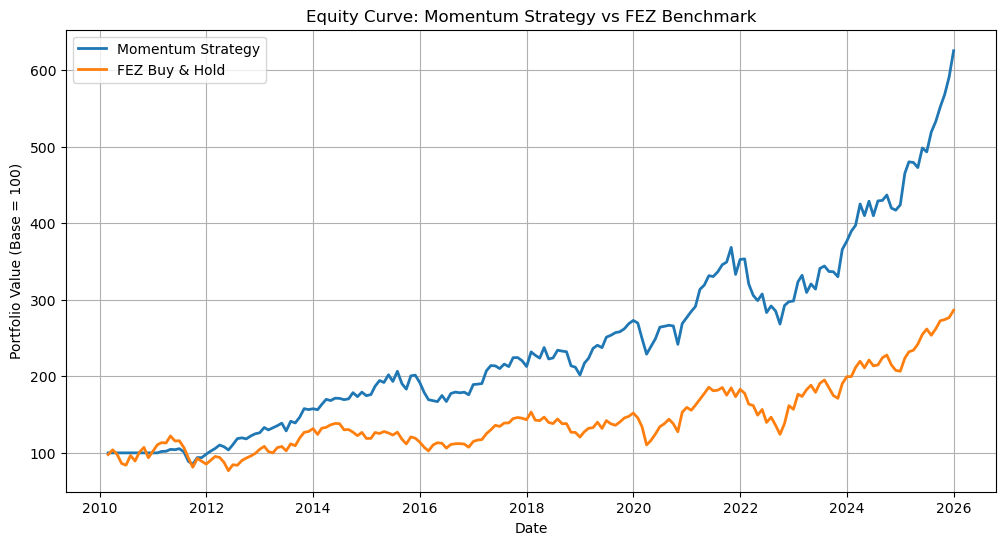

In [6]:
benchmark_data = yf.download("FEZ",start="2010-01-01",end="2025-12-31",auto_adjust=False,progress=True)
benchmark_prices = benchmark_data["Adj Close"].copy()
 
# Pour s'assurer que benchmark_prices est une Series
if isinstance(benchmark_prices, pd.DataFrame):
    benchmark_prices = benchmark_prices.iloc[:, 0]

benchmark_prices = benchmark_prices.sort_index().ffill()
benchmark_prices = benchmark_prices.resample("ME").last()
benchmark_returns = benchmark_prices.pct_change().dropna()
benchmark_equity = 100 * (1 + benchmark_returns).cumprod()
print(benchmark_returns.head(15))



common_index = strategy_returns.index.intersection(benchmark_returns.index)
strategy_returns_aligned = strategy_returns.loc[common_index]
strategy_equity_aligned = strategy_equity.loc[common_index]
benchmark_returns_aligned = benchmark_returns.loc[common_index]
benchmark_equity_aligned = benchmark_equity.loc[common_index]
selected_tickers_aligned = selected_tickers_table.loc[common_index]

# Convert 1-column DataFrames to Series if needed
if isinstance(strategy_returns_aligned, pd.DataFrame):
    strategy_returns_aligned = strategy_returns_aligned.iloc[:, 0]

if isinstance(strategy_equity_aligned, pd.DataFrame):
    strategy_equity_aligned = strategy_equity_aligned.iloc[:, 0]

if isinstance(benchmark_returns_aligned, pd.DataFrame):
    benchmark_returns_aligned = benchmark_returns_aligned.iloc[:, 0]

if isinstance(benchmark_equity_aligned, pd.DataFrame):
    benchmark_equity_aligned = benchmark_equity_aligned.iloc[:, 0]

print("First aligned date:", common_index.min())
print("Last aligned date:", common_index.max())



plt.figure(figsize=(12, 6))
plt.plot(strategy_equity_aligned, label="Momentum Strategy", linewidth=2)
plt.plot(benchmark_equity_aligned, label="FEZ Buy & Hold", linewidth=2)
plt.title("Equity Curve: Momentum Strategy vs FEZ Benchmark")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (Base = 100)")
plt.legend()
plt.grid(True)
plt.show()

## 10. Sauvegarde des résultats

On sauvegarde les sorties principales du backtest pour pouvoir les réutiliser
dans les notebooks suivants :
- le rendement mensuel de la stratégie momentum
- la valeur cumulée de la stratégie
- le rendement mensuel du benchmark FEZ
- la valeur cumulée du benchmark
- les tickers sélectionnés chaque mois

In [7]:
backtest_summary = pd.DataFrame({"FEZ Return": benchmark_returns_aligned,"FEZ Equity": benchmark_equity_aligned,"Strategy Return": strategy_returns_aligned,"Strategy Equity": strategy_equity_aligned})

# Ajouter les tickers tenues pendant le mois
backtest_summary["Selected Tickers"] = selected_tickers_aligned["Selected Tickers"]

backtest_summary.to_csv("../data/backtest_summary.csv")

print("File saved successfully:")
print("- ../data/backtest_summary.csv")

backtest_summary.head(15)

File saved successfully:
- ../data/backtest_summary.csv


,FEZ Return,FEZ Equity,Strategy Return,Strategy Equity,Selected Tickers
Date,,,,,
2010-02-28,-0.022169,97.783126,0.000000,100.000000,
2010-03-31,0.063879,104.029451,0.000000,100.000000,
2010-04-30,-0.057583,98.039074,0.000000,100.000000,
2010-05-31,-0.121113,86.165293,0.000000,100.000000,
2010-06-30,-0.026597,83.873534,0.000000,100.000000,
2010-07-31,0.151455,96.576640,0.000000,100.000000,
2010-08-31,-0.074432,89.388237,0.000000,100.000000,
2010-09-30,0.129022,100.921314,0.000000,100.000000,
2010-10-31,0.061836,107.161884,0.000000,100.000000,


## Conclusion

Dans ce notebook, le signal momentum a été transformé en portefeuille investi :

- les actions du top 30% ont été sélectionnées chaque mois
- les poids ont été construits en equal weight
- le portefeuille a été rééquilibré mensuellement
- les rendements bruts de la stratégie ont été calculés
- la stratégie a été comparée à un benchmark passif européen (FEZ)
- les tickers effectivement sélectionnés ont été affichés mois par mois

Ce notebook fournit la base du backtest brut,
qui sera enrichi ensuite par les métriques, les coûts et l’analyse de risque.